In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.rcParams.update({"text.usetex": True, "font.family": "Modern"})

In [2]:
oof_predictions_path = r"C:\Users\user\Repositories\fault-classification-localization\outputs\hv_double_line_90kv\y_fault_location\mlp_regressor\run_20260129_095427\oof_predictions.parquet"

df_oof = pd.read_parquet(oof_predictions_path)

print("Available columns in OOF predictions dataframe: %s" % df_oof.columns.tolist())

display(df_oof)

Available columns in OOF predictions dataframe: ['sample_id', 'event_type', 'fault_class', 'status', 'y_fault_line', 'y_fault_location', 'fold', 'y_true', 'y_pred']


,sample_id,event_type,fault_class,status,y_fault_line,y_fault_location,fold,y_true,y_pred
0,1,flt_2phg_shc,9,fault_start,Line_2_3_a,87.564949,1,87.564949,71.990852
1,1,flt_2phg_shc,9,fault_start,Line_2_3_a,87.564949,1,87.564949,83.650887
2,1,flt_2phg_shc,9,fault_start,Line_2_3_a,87.564949,1,87.564949,78.248848
3,1,flt_2phg_shc,9,fault_start,Line_2_3_a,87.564949,1,87.564949,95.465073
4,1,flt_2phg_shc,9,fault_start,Line_2_3_a,87.564949,1,87.564949,82.385712
...,...,...,...,...,...,...,...,...,...
81193,9145,flt_2phg_shc,7,fault_start,Line_2_3_a,88.708923,5,88.708923,74.941216
81194,9145,flt_2phg_shc,7,fault_start,Line_2_3_a,88.708923,5,88.708923,87.709366
81195,9145,flt_2phg_shc,7,fault_start,Line_2_3_a,88.708923,5,88.708923,78.331841
81196,9145,flt_2phg_shc,7,fault_start,Line_2_3_a,88.708923,5,88.708923,83.701965


In [ ]:
# Calculate mae per fold (y_true - y_pred)
mae_per_fold = []
for fold in df_oof["fold"].unique():
    fold_df = df_oof[df_oof["fold"] == fold]
    mae = np.mean(np.abs(fold_df["y_true"] - fold_df["y_pred"]))
    mae_per_fold.append((fold, mae))

print("MAE per fold:")
for fold, mae in mae_per_fold:
    print(f"Fold {fold}: MAE = {mae:.4f}")

# CAlculate mean and std of mae across folds
mean_mae = np.mean([mae for _, mae in mae_per_fold])
std_mae = np.std([mae for _, mae in mae_per_fold])

print(f"Mean MAE across folds: {mean_mae:.4f}")
print(f"Std of MAE across folds: {std_mae:.4f}")

MAE per fold:
Fold 1: MAE = 9.3908
Fold 2: MAE = 10.2368
Fold 3: MAE = 9.7840
Fold 4: MAE = 10.3028
Fold 5: MAE = 9.8583
Mean MAE across folds: 9.9146
Std of MAE across folds: 0.3314


In [3]:
# check if any unqiue "sample_id" appears in combinatin with multiple "fold" values (it should not)
sample_fold_counts = df_oof.groupby("sample_id")["fold"].nunique()
if (sample_fold_counts > 1).any():
    problematic_samples = sample_fold_counts[sample_fold_counts > 1]
    raise ValueError(
        f"Some sample_id values appear in multiple folds: {problematic_samples}"
    )

In [4]:
df = df_oof.copy()

# Absolute and signed error
df["abs_error"] = np.abs(df["y_pred"] - df["y_true"])
df["signed_error"] = df["y_pred"] - df["y_true"]

# Distance bins (engineering-friendly)
bins = np.arange(0, 110, 10)  # 0–10, …, 90–100
df["dist_bin"] = pd.cut(df["y_true"], bins=bins, right=False)

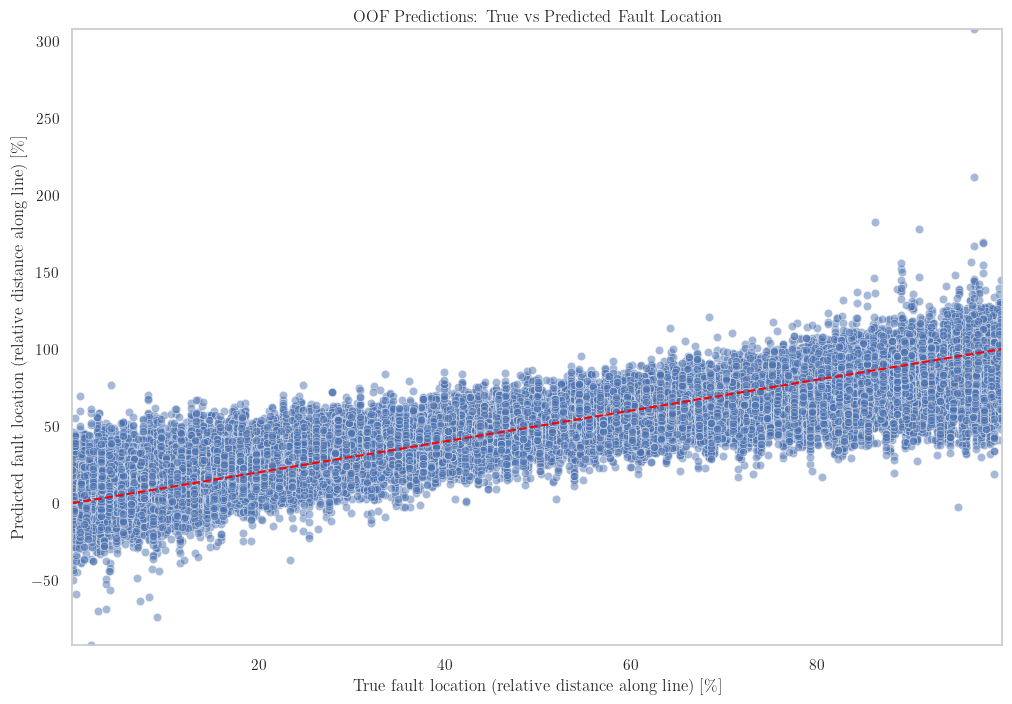

In [5]:
# plot y_true vs y_pred scatter
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x="y_true", y="y_pred", alpha=0.5)
plt.plot([0, 100], [0, 100], color="red", linestyle="--")
plt.xlim(df["y_true"].min(), df["y_true"].max())
plt.ylim(df["y_pred"].min(), df["y_pred"].max())
plt.xlabel("True fault location (relative distance along line) [\\%]")
plt.ylabel("Predicted fault location (relative distance along line) [\\%]")
plt.title("OOF Predictions: True vs Predicted Fault Location")
plt.grid()
plt.show()

In [6]:
error_by_bin = (
    df.groupby("dist_bin", observed=True)[["abs_error"]]
    .agg(
        n=("abs_error", "size"),
        mae=("abs_error", "mean"),
        rmse=("abs_error", lambda x: np.sqrt((x**2).mean())),
    )
    .reset_index()
)


print(error_by_bin)

    dist_bin     n        mae       rmse
0    [0, 10)  8460  11.252196  14.974375
1   [10, 20)  8199   9.983959  13.124131
2   [20, 30)  8118   8.744253  11.441234
3   [30, 40)  7794   8.070061  10.411391
4   [40, 50)  8289   7.453601   9.581883
5   [50, 60)  8001   7.626562   9.735622
6   [60, 70)  8163   8.403843  10.816836
7   [70, 80)  8127  10.038632  12.920764
8   [80, 90)  8199  12.554216  16.262998
9  [90, 100)  7848  15.059171  19.512357


In [7]:
error_dist = (
    df.groupby("dist_bin", observed=True)["abs_error"]
    .describe(percentiles=[0.5, 0.9, 0.95])
    .reset_index()
)


print(error_dist)

    dist_bin   count       mean        std       min        50%        90%  \
0    [0, 10)  8460.0  11.252196   9.880867  0.000226   8.675720  24.620943   
1   [10, 20)  8199.0   9.983959   8.518933  0.000233   7.817862  21.643909   
2   [20, 30)  8118.0   8.744253   7.378793  0.001499   6.803618  19.160016   
3   [30, 40)  7794.0   8.070061   6.578504  0.000259   6.469833  16.891867   
4   [40, 50)  8289.0   7.453601   6.021684  0.000549   6.099754  15.623950   
5   [50, 60)  8001.0   7.626562   6.051650  0.000175   6.260845  15.941376   
6   [60, 70)  8163.0   8.403843   6.810656  0.001575   6.786991  17.474712   
7   [70, 80)  8127.0  10.038632   8.135118  0.003395   8.111557  21.184315   
8   [80, 90)  8199.0  12.554216  10.338752  0.000366   9.843414  27.278809   
9  [90, 100)  7848.0  15.059171  12.408588  0.001244  12.123222  31.936502   

         95%         max  
0  31.086722   94.002624  
1  27.260244   53.681660  
2  23.445701   60.508059  
3  20.865188   50.172798  
4  18.

In [8]:
bias_by_bin = (
    df.groupby("dist_bin", observed=True)
    .agg(
        bias_mean=("signed_error", "mean"),
        bias_std=("signed_error", "std"),
    )
    .reset_index()
)


print(bias_by_bin)

    dist_bin  bias_mean   bias_std
0    [0, 10)   4.029989  14.422749
1   [10, 20)   3.777703  12.569449
2   [20, 30)   3.662226  10.839945
3   [30, 40)   2.570603  10.089704
4   [40, 50)   1.253087   9.500165
5   [50, 60)  -0.319661   9.730981
6   [60, 70)  -2.367666  10.555176
7   [70, 80)  -5.099454  11.872618
8   [80, 90)  -7.351972  14.507214
9  [90, 100) -10.107881  16.691265


In [9]:
calibration = (
    df.groupby("dist_bin", observed=True)
    .agg(
        y_true_center=("y_true", "mean"),
        y_pred_mean=("y_pred", "mean"),
    )
    .reset_index()
)


print(calibration)

    dist_bin  y_true_center  y_pred_mean
0    [0, 10)       4.973139     9.003128
1   [10, 20)      14.981696    18.759399
2   [20, 30)      25.148604    28.810829
3   [30, 40)      35.062022    37.632626
4   [40, 50)      44.951120    46.204208
5   [50, 60)      54.973713    54.654053
6   [60, 70)      65.091653    62.723988
7   [70, 80)      74.965607    69.866158
8   [80, 90)      84.962400    77.610428
9  [90, 100)      95.222291    85.114410


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def fl_location_table(
    df_oof: pd.DataFrame,
    bin_width: int = 10,
    tol: float = 10.0,
) -> pd.DataFrame:
    """
    Compute fault-localization error statistics conditioned on true fault location.

    Returns a table with one row per location bin.
    """
    required_cols = {"y_true", "y_pred"}
    missing = required_cols - set(df_oof.columns)
    if missing:
        raise ValueError(f"Missing required columns in df_oof: {sorted(missing)}")

    df = df_oof.copy()
    df["abs_error"] = np.abs(df["y_pred"] - df["y_true"])

    # Use list of floats to keep type-checkers happy and make intent explicit
    bins = list(np.arange(0.0, 100.0 + bin_width, bin_width))

    df["dist_bin"] = pd.cut(
        df["y_true"].astype(float),
        bins=bins,
        right=False,  # left-closed: [0,10), ...
        include_lowest=True,
    )

    def rmse(x) -> float:
        x = np.asarray(x, dtype=float)
        return float(np.sqrt(np.mean(x * x)))

    table = (
        df.groupby("dist_bin", observed=True)
        .agg(
            n=("abs_error", "size"),
            mae=("abs_error", "mean"),
            rmse=("abs_error", rmse),
            p50=(
                "abs_error",
                lambda x: float(np.quantile(np.asarray(x, dtype=float), 0.50)),
            ),
            p90=(
                "abs_error",
                lambda x: float(np.quantile(np.asarray(x, dtype=float), 0.90)),
            ),
            p95=(
                "abs_error",
                lambda x: float(np.quantile(np.asarray(x, dtype=float), 0.95)),
            ),
            cov_tol=(
                "abs_error",
                lambda x: float(np.mean(np.asarray(x, dtype=float) <= tol)),
            ),
        )
        .reset_index()
    )

    # Round for better readability to 3 decimal places
    float_cols = [col for col in table.columns if table[col].dtype.kind == "f"]
    table[float_cols] = table[float_cols].round(3)

    return table

In [31]:
def plot_fl_location_envelope(
    table: pd.DataFrame,
    bin_width: int = 10,
    figsize: tuple = (8.5, 5.6),
) -> None:
    import numpy as np
    import matplotlib.pyplot as plt

    required_cols = {"dist_bin", "p50", "p95"}
    missing = required_cols - set(table.columns)
    if missing:
        raise ValueError(f"Missing required columns in table: {sorted(missing)}")

    # --- Consistent paper colors ---
    fau_blue = "#04316A"  # primary line / consistent with prior figures
    accent_orange = "#D17C2F"  # muted accent for upper-tail curve
    fill_blue = "#6E86A6"  # soft blue-gray envelope
    grid_gray = "#C8C8C8"
    bound_gray = "#9AA7B5"

    # Bin centers
    centers = np.array(
        [iv.left + (iv.right - iv.left) / 2 for iv in table["dist_bin"]],
        dtype=float,
    )

    p50 = table["p50"].to_numpy(dtype=float)
    p95 = table["p95"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    # Envelope first, so lines stay visually dominant
    ax.fill_between(
        centers,
        p50,
        p95,
        color=fill_blue,
        alpha=0.20,
        linewidth=0,
        label="50--95\\% envelope",
        zorder=1,
    )

    # Median and upper-tail curves
    ax.plot(
        centers,
        p50,
        color=fau_blue,
        marker="o",
        markersize=4.5,
        linewidth=2.0,
        label="Median error",
        zorder=3,
    )
    ax.plot(
        centers,
        p95,
        color=accent_orange,
        marker="o",
        markersize=4.5,
        linewidth=2.0,
        label="95th percentile error",
        zorder=3,
    )

    # Line boundaries
    ax.axvline(0, color=bound_gray, linestyle=":", linewidth=1.0, zorder=2)
    ax.axvline(100, color=bound_gray, linestyle=":", linewidth=1.0, zorder=2)

    # Axes labels
    ax.set_xlabel(f"True fault location [\\%] ({bin_width}\\% bins)", fontsize=18)
    ax.set_ylabel("Localization error [\\%]", fontsize=18)

    # Axis limits and ticks
    ax.set_xlim(-2, 102)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_ylim(0, max(p95) * 1.08)

    ax.tick_params(axis="both", labelsize=16)

    # Light, unobtrusive grid
    ax.grid(axis="y", color=grid_gray, linewidth=0.8, alpha=0.8)
    ax.grid(axis="x", visible=False)

    # Clean frame
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend
    ax.legend(
        loc="upper center",
        fontsize=16.5,
        frameon=True,
        framealpha=0.9,
        edgecolor="#DDDDDD",
    )

    plt.tight_layout()
    plt.savefig(
        "fault_localization_error.pdf",
        bbox_inches="tight",
        pad_inches=0.00,
    )

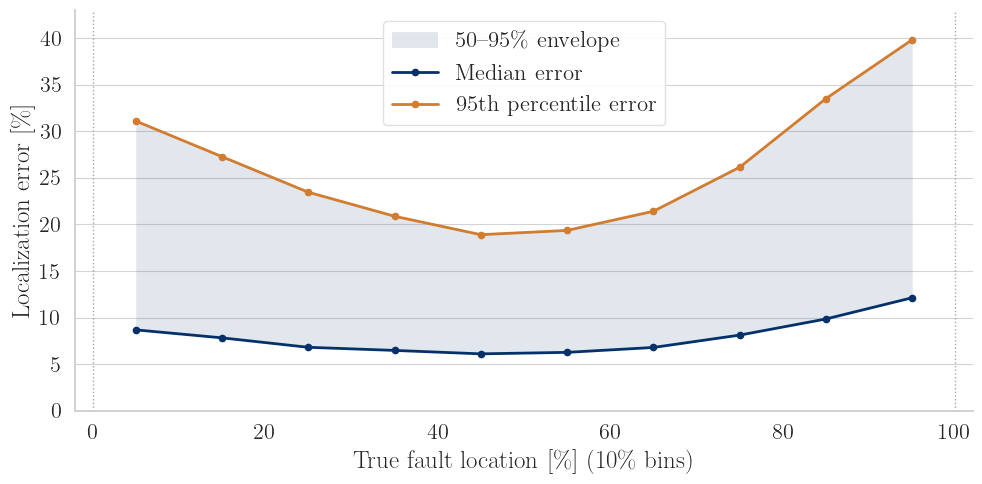

In [32]:
table = fl_location_table(df_oof, bin_width=10, tol=10.0)
plot_fl_location_envelope(table, figsize=(10, 5))
plt.show()

In [12]:
print(table)

        dist_bin     n     mae    rmse     p50     p90     p95  cov_tol
0    [0.0, 10.0)  8460  11.252  14.974   8.676  24.621  31.087    0.556
1   [10.0, 20.0)  8199   9.984  13.124   7.818  21.644  27.260    0.602
2   [20.0, 30.0)  8118   8.744  11.441   6.804  19.160  23.446    0.663
3   [30.0, 40.0)  7794   8.070  10.411   6.470  16.892  20.865    0.688
4   [40.0, 50.0)  8289   7.454   9.582   6.100  15.624  18.887    0.729
5   [50.0, 60.0)  8001   7.627   9.736   6.261  15.941  19.347    0.717
6   [60.0, 70.0)  8163   8.404  10.817   6.787  17.475  21.398    0.668
7   [70.0, 80.0)  8127  10.039  12.921   8.112  21.184  26.125    0.592
8   [80.0, 90.0)  8199  12.554  16.263   9.843  27.279  33.490    0.505
9  [90.0, 100.0)  7848  15.059  19.512  12.123  31.937  39.811    0.429


In [13]:
import pandas as pd


def df_to_latex_tabular(
    df: pd.DataFrame,
    caption: str,
    label: str,
    *,
    float_fmt: str = "{:.3f}",
    index: bool = False,
    position: str = "t",
    column_format: str | None = None,
    use_booktabs: bool = True,
) -> str:
    """
    Convert a DataFrame to a LaTeX table environment with tabular + booktabs.
    - Escapes % in column names automatically (e.g., '%' -> '\\%').
    - Formats floats with `float_fmt`.
    - Uses DataFrame.to_latex under the hood (works well with acmart).
    """
    df_ltx = df.copy()

    # Ensure nice column headers (escape % etc.)
    df_ltx.columns = [str(c).replace("%", r"\%") for c in df_ltx.columns]

    # If column_format not provided, infer a reasonable one:
    # first column left, others right-aligned
    if column_format is None:
        ncols = df_ltx.shape[1] + (1 if index else 0)
        if ncols <= 0:
            raise ValueError("DataFrame has no columns.")
        column_format = "l" + "r" * (ncols - 1)

    latex_tabular = df_ltx.to_latex(
        index=index,
        escape=False,  # we already handle % in headers; keep Interval strings as-is
        float_format=lambda x: float_fmt.format(x),
        column_format=column_format,
        bold_rows=False,
        longtable=False,
        caption=caption,
        label=label,
        position=position,
        multicolumn=True,
        multicolumn_format="c",
        na_rep="",
        decimal=".",
    )

    # Pandas emits a full table environment already. Return as-is.
    return latex_tabular


def format_dist_bin_0_10(iv) -> str:
    """Convert pandas Interval like [0.0, 10.0) -> '0--10' (LaTeX-friendly)."""
    try:
        left = int(round(float(iv.left)))
        right = int(round(float(iv.right)))
        return f"{left}--{right}"
    except Exception:
        # fallback (in case it's already a string)
        s = str(iv)
        return s.replace("[", "").replace(")", "").replace("]", "").replace(", ", "--")


def make_fl_location_table_latex(
    table: pd.DataFrame, bin_width: int = 10, tol: float = 10.0
) -> str:
    # --- select + copy ---
    df = table[["dist_bin", "n", "mae", "p95"]].copy()

    # --- format bins as 0--10 ---
    df["dist_bin"] = df["dist_bin"].map(format_dist_bin_0_10)

    # --- compute diff to mean MAE ---
    mae_mean = df["mae"].mean()
    df["diff_mae"] = df["mae"] - mae_mean

    # --- rename columns (LaTeX-safe strings) ---
    df = df.rename(
        columns={
            "dist_bin": r"Location [\%]",
            "n": r"$n$",
            "mae": r"MAE [\%]",
            "diff_mae": r"$\Delta$MAE [\%]",
            "p95": r"P95 [\%]",
        }
    )

    # --- round numeric columns ---
    num_cols = [c for c in df.columns if c != r"Location [\%]"]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce").round(3)

    latex = df.to_latex(
        index=False,
        escape=False,  # keep LaTeX in headers
        column_format="lrrrr",
        float_format=lambda x: f"{x:.3f}",
        caption=rf"Location-binned fault localization errors ({bin_width}\% bins).",
        label="tab:fl_error_by_location_bins",
        position="t",
    )
    return latex

In [14]:
# --- usage ---
latex = make_fl_location_table_latex(table, bin_width=10, tol=10.0)
print(latex)

\begin{table}[t]
\caption{Location-binned fault localization errors (10\% bins).}
\label{tab:fl_error_by_location_bins}
\begin{tabular}{lrrrr}
\toprule
Location [\%] & $n$ & MAE [\%] & P95 [\%] & $\Delta$MAE [\%] \\
\midrule
0--10 & 8460 & 11.252 & 31.087 & 1.333 \\
10--20 & 8199 & 9.984 & 27.260 & 0.065 \\
20--30 & 8118 & 8.744 & 23.446 & -1.175 \\
30--40 & 7794 & 8.070 & 20.865 & -1.849 \\
40--50 & 8289 & 7.454 & 18.887 & -2.465 \\
50--60 & 8001 & 7.627 & 19.347 & -2.292 \\
60--70 & 8163 & 8.404 & 21.398 & -1.515 \\
70--80 & 8127 & 10.039 & 26.125 & 0.120 \\
80--90 & 8199 & 12.554 & 33.490 & 2.635 \\
90--100 & 7848 & 15.059 & 39.811 & 5.140 \\
\bottomrule
\end{tabular}
\end{table}



Mean MAE across bins: 9.919 %
Std of MAE across bins: 2.440 %
